### Importing Req. Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping

2026-07-26 19:40:02.640468: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-26 19:40:02.792974: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785094802.851001   25668 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785094802.866315   25668 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785094802.966636   25668 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

### loading MNIST + preprocessing

In [2]:


dataset_path = "mnist_png"

train_folder = os.path.join(dataset_path, "training")
test_folder = os.path.join(dataset_path, "testing")


def fetch_digits(folder_name):
    pic_list = []
    tag_list = []

    for one_tag in sorted(os.listdir(folder_name)):
        tag_path = os.path.join(folder_name, one_tag)

        if not os.path.isdir(tag_path):
            continue

        for one_pic in os.listdir(tag_path):
            pic_path = os.path.join(tag_path, one_pic)

            img_box = load_img(pic_path, color_mode="grayscale", target_size=(28, 28))
            img_box = img_to_array(img_box) / 255.0

            pic_list.append(img_box)
            tag_list.append(int(one_tag))

    return np.array(pic_list), np.array(tag_list)


digit_train, train_label = fetch_digits(train_folder)
digit_test, test_label = fetch_digits(test_folder)

print(digit_train.shape)
print(digit_test.shape)
print(train_label.shape)
print(test_label.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)
(60000,)
(10000,)


### adding Noise

In [3]:
noise_lvl = 0.5

train_disturbed = digit_train + noise_lvl * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=digit_train.shape
)

test_disturbed = digit_test + noise_lvl * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=digit_test.shape
)

train_disturbed = np.clip(train_disturbed, 0.0, 1.0)
test_disturbed = np.clip(test_disturbed, 0.0, 1.0)

### noise

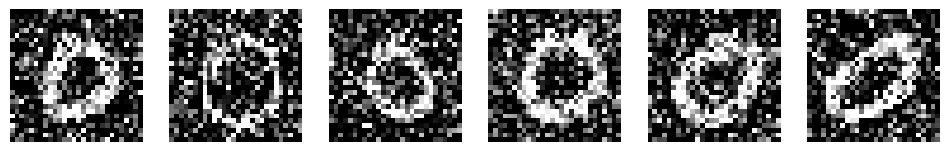

In [4]:
plt.figure(figsize=(12,2))

for idx in range(6):
    plt.subplot(1,6,idx+1)
    plt.imshow(train_disturbed[idx].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.show()

### Denoise AE

In [5]:
entry = Input(shape=(28,28,1))

layer_a = Conv2D(32, (3,3), activation="relu", padding="same")(entry)
layer_a = MaxPooling2D((2,2), padding="same")(layer_a)

layer_b = Conv2D(64, (3,3), activation="relu", padding="same")(layer_a)
layer_b = MaxPooling2D((2,2), padding="same")(layer_b)

layer_c = Conv2D(64, (3,3), activation="relu", padding="same")(layer_b)
layer_c = UpSampling2D((2,2))(layer_c)

layer_d = Conv2D(32, (3,3), activation="relu", padding="same")(layer_c)
layer_d = UpSampling2D((2,2))(layer_d)

exit_layer = Conv2D(1, (3,3), activation="sigmoid", padding="same")(layer_d)

clean_net = Model(entry, exit_layer)

clean_net.compile(
    optimizer=Adam(),
    loss="binary_crossentropy"
)

clean_net.summary()

I0000 00:00:1785094820.325954   25668 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3537 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

### model training

In [6]:
stop_now = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

training_log = clean_net.fit(
    train_disturbed,
    digit_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(test_disturbed, digit_test),
    callbacks=[stop_now]
)

Epoch 1/20


I0000 00:00:1785094822.650513   25738 service.cc:152] XLA service 0x7ea3dc016700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785094822.650573   25738 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-07-26 19:40:22.694593: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785094822.910010   25738 cuda_dnn.cc:529] Loaded cuDNN version 90300


 34/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4472

I0000 00:00:1785094825.278106   25738 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.1590 - val_loss: 0.1134
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1097 - val_loss: 0.1052
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1038 - val_loss: 0.1012
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1012 - val_loss: 0.0996
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0997 - val_loss: 0.0982
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0986 - val_loss: 0.0981
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0978 - val_loss: 0.0968
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0972 - val_loss: 0.0964
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0965 - val_loss: 0.0957
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0960 - val_loss: 0.0958
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0956 - val_loss: 0.0956
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0

### training graph

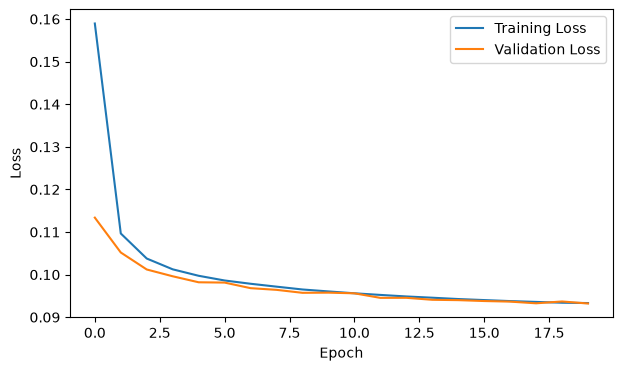

In [7]:
plt.figure(figsize=(7,4))


plt.plot(training_log.history["loss"], label="Training Loss")
plt.plot(training_log.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### gen denoise img

In [8]:
restored_imgs = clean_net.predict(test_disturbed)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


### result

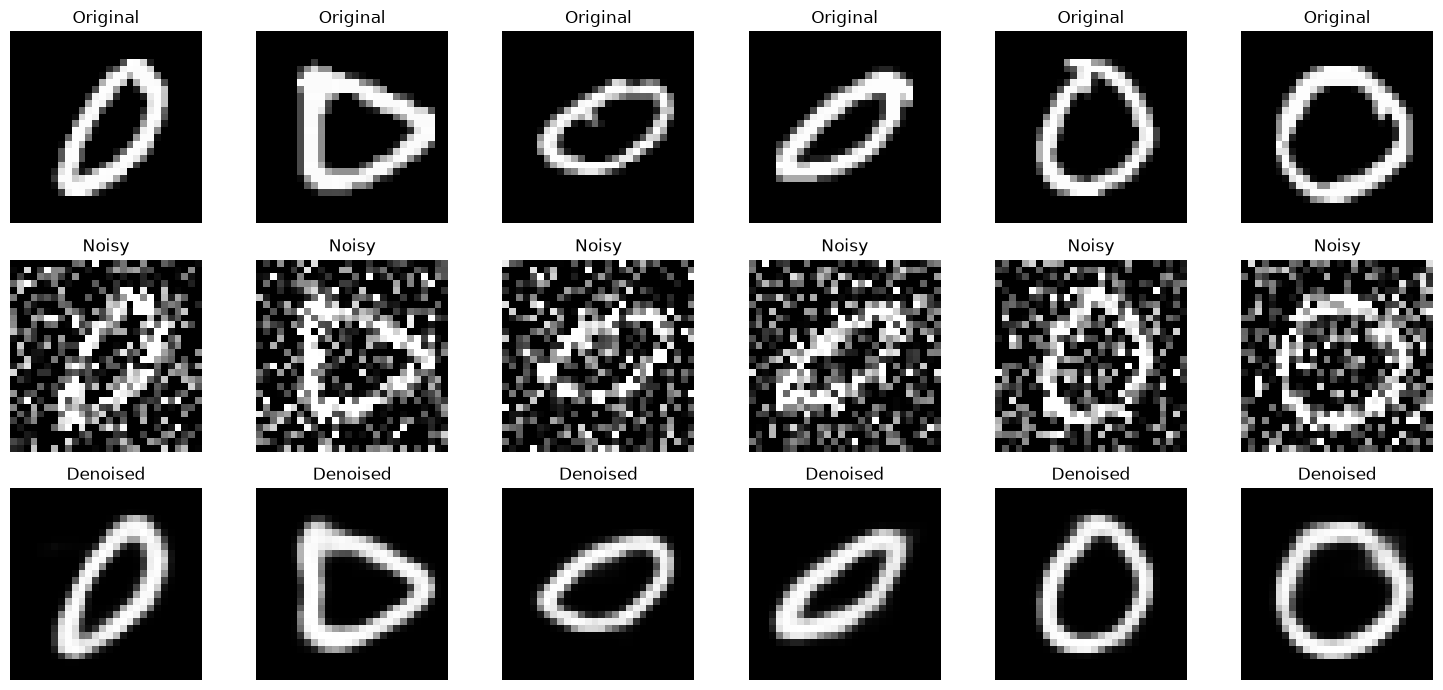

In [9]:
sample_count = 6

plt.figure(figsize=(15,7))

for pos in range(sample_count):

    plt.subplot(3, sample_count, pos + 1)
    plt.imshow(digit_test[pos].reshape(28,28), cmap="gray")
    plt.axis("off")
    plt.title("Original")

    plt.subplot(3, sample_count, pos + 1 + sample_count)
    plt.imshow(test_disturbed[pos].reshape(28,28), cmap="gray")
    plt.axis("off")
    plt.title("Noisy")

    plt.subplot(3, sample_count, pos + 1 + 2*sample_count)
    plt.imshow(restored_imgs[pos].reshape(28,28), cmap="gray")
    plt.axis("off")
    plt.title("Denoised")

plt.tight_layout()
plt.show()

### MSE PSNR

In [10]:
mse_val = np.mean((restored_imgs - digit_test) ** 2)

psnr_val = tf.image.psnr(
    restored_imgs,
    digit_test,
    max_val=1.0
)

print("Mean Squared Error :", mse_val)
print("Average PSNR :", np.mean(psnr_val.numpy()), "dB")

Mean Squared Error : 0.010173092
Average PSNR : 20.286306 dB


### saving model

In [11]:
clean_net.save("mnist_denoising_autoencoder.keras")

### multiple noise level

In [12]:
noise_vals = [0.3, 0.5, 0.7]

print("Noise Level\tMSE\t\tPSNR (dB)")

for one_noise in noise_vals:

    noisy_pack = digit_test + one_noise * np.random.normal(
        0,
        1,
        digit_test.shape
    )

    noisy_pack = np.clip(noisy_pack, 0, 1)

    rebuilt_pack = clean_net.predict(noisy_pack, verbose=0)

    mse_now = np.mean((rebuilt_pack - digit_test) ** 2)

    psnr_now = tf.image.psnr(
        rebuilt_pack,
        digit_test,
        max_val=1.0
    )

    print(f"{one_noise:.1f}\t\t{mse_now:.6f}\t{np.mean(psnr_now):.2f}")

Noise Level	MSE		PSNR (dB)
0.3		0.005941	22.65
0.5		0.010141	20.29
0.7		0.019875	17.31


# Observations

- Model remove most of the random noise from the images.
- Thick digits like **0, 6, 8, 9** looks more clear after denoising.
- Thin digits like **1** and **7** lose little bit edge details.
- Training loss and validation loss both decrease and stay close, so model not overfitting much.
- MSE value is low and PSNR is high, means output image is close to original one.
- When noise level increase from **0.3 → 0.7**, reconstruction become little difficult and image quality decrease.
- EarlyStopping was configured with patience=3 but never triggered here, since validation loss kept improving almost every epoch, it monitored the run without needing to intervene
- Overall model give good denoising result on MNIST dataset.